## 의료비 데이터 전처리 + 탐색적 데이터 분석
- 결측치 처리 -> 이상치 처리 -> EDA(라벨있는 상태) -> 인코딩 -> 파생변수/스케일링 -> 저장

### 라이브러리 불러오기, 데이터 로드

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('insurance_missing.csv')

In [56]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,56.0,female,22.7,4.0,no,southwest,3230.92
1,22.0,female,28.2,0.0,no,southeast,1601.92
2,26.0,male,NaN,3.0,no,southeast,4764.30
3,29.0,female,29.1,0.0,yes,northeast,26255.60
4,26.0,male,35.0,0.0,no,northeast,3914.46


In [57]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       500 non-null    float64
 1   sex       500 non-null    str    
 2   bmi       470 non-null    float64
 3   children  485 non-null    float64
 4   smoker    500 non-null    str    
 5   region    480 non-null    str    
 6   charges   500 non-null    float64
dtypes: float64(4), str(3)
memory usage: 27.5 KB


In [58]:
df.shape # (행개수, 열개수)--> 속성

(500, 7)

### 결측치 처리

In [59]:
# 결측치 확인
df.isnull().sum()

age          0
sex          0
bmi         30
children    15
smoker       0
region      20
charges      0
dtype: int64

In [60]:
# 결측 비율이 50% 초과 --> 컬럼을 삭제
# 평균 : 결측 비율을 제대로 알려고 평균을 구한다.
missing_ratio = df.isnull().mean()
missing_ratio

age         0.00
sex         0.00
bmi         0.06
children    0.03
smoker      0.00
region      0.04
charges     0.00
dtype: float64

In [61]:
missing_ratio[missing_ratio>0.02]

bmi         0.06
children    0.03
region      0.04
dtype: float64

In [62]:
drop_cols = missing_ratio[missing_ratio>0.5].index.tolist()

In [63]:
df.drop(columns=drop_cols)

,age,sex,bmi,children,smoker,region,charges
0,56.0,female,22.7,4.0,no,southwest,3230.92
1,22.0,female,28.2,0.0,no,southeast,1601.92
2,26.0,male,NaN,3.0,no,southeast,4764.30
3,29.0,female,29.1,0.0,yes,northeast,26255.60
4,26.0,male,35.0,0.0,no,northeast,3914.46
...,...,...,...,...,...,...,...
495,49.0,male,27.1,0.0,no,southwest,7802.82
496,63.0,male,26.2,1.0,no,northeast,3967.26
497,34.0,female,34.6,2.0,no,southwest,3195.25
498,54.0,female,36.3,0.0,no,northeast,5341.74


In [64]:
df.select_dtypes(include='number') # 숫자형만 보자

,age,bmi,children,charges
0,56.0,22.7,4.0,3230.92
1,22.0,28.2,0.0,1601.92
2,26.0,NaN,3.0,4764.30
3,29.0,29.1,0.0,26255.60
4,26.0,35.0,0.0,3914.46
...,...,...,...,...
495,49.0,27.1,0.0,7802.82
496,63.0,26.2,1.0,3967.26
497,34.0,34.6,2.0,3195.25
498,54.0,36.3,0.0,5341.74


In [65]:
df.select_dtypes(include='number').columns # 숫자형의 컬럼이름을 알고 싶었다.

Index(['age', 'bmi', 'children', 'charges'], dtype='str')

In [66]:
num_cols_na = df.select_dtypes(include='number').columns
num_cols_na

Index(['age', 'bmi', 'children', 'charges'], dtype='str')

In [67]:
num_cols_na = num_cols_na[df[num_cols_na].isnull().any()]

In [68]:
# 숫자형을 제외한 컬럼 (범주형)
df.select_dtypes(exclude='number').columns

Index(['sex', 'smoker', 'region'], dtype='str')

In [69]:
cat_cols_na = df.select_dtypes(exclude='number').columns
cat_cols_na = cat_cols_na[df[cat_cols_na].isnull().any()]

In [70]:
# 결측치를 최빈값으로 채운다.
df['region'] = df['region'].fillna(df['region'].mode()[0])

In [71]:
# 숫자형 컬럼의 결측치를 중앙값으로 채운다.
for c in num_cols_na:
    df[c] = df[c].fillna(df[c].median())

In [72]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

### 이상치 처리

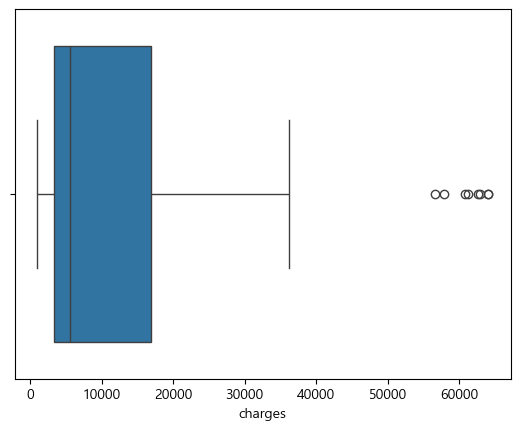

In [73]:
# 의료비(charges) 박스 플롯 확인
sns.boxplot(x=df['charges'])
plt.show()

In [74]:
# Q1 (1사분위수) 25%
q1 = df['charges'].quantile(.25)

# Q3 (3사분위수) 75%
q3 = df['charges'].quantile(.75)

In [75]:
iqr = q3- q1
iqr

np.float64(13570.9225)

In [76]:
# 하한
lower = q1 - 1.5*iqr
lower

np.float64(-16969.27125)

In [77]:
# 상한
upper = q3 + 1.5*iqr
upper

np.float64(37314.41875)

In [78]:
# 이상치의 개수
n_outlier = (df['charges'] < lower) | (df['charges'] > upper)
n_outlier.sum()

np.int64(8)

In [79]:
# 의료비 데이터는 표본 수가 적을수록 뒤쪽 EDA(그룹 비교)에서 신뢰도가 떨어지므로 표본을 유지하면서
# 극단값만 완화하는 capping이 더 적합하다.
# 고액 의료비를 내는 사람이 흡연자일수도 있다.

# .clip() : 값의 범위를 강제로 잘라내는 함수
#           범위 밖으로 튀어나온 값을 범위 안으로 눌러넣는다.
#           값이 lower보다 작으면 lower로 바꾼다.
#           값이 upper보다 크면 upper로 바꾼다.
df['charges'] = df['charges'].clip(lower, upper)

In [80]:
# 기초 통계량 - describe()
df.describe()

,age,bmi,children,charges
count,500.000000,500.000000,500.00000,500.000000
mean,40.782000,30.196000,1.39000,10073.496920
std,13.322517,5.719427,1.39204,9885.701215
min,18.000000,15.000000,0.00000,1000.000000
25%,29.000000,26.400000,0.00000,3387.112500
50%,41.000000,30.200000,1.00000,5498.770000
75%,51.250000,34.200000,2.00000,16958.035000
max,64.000000,45.400000,5.00000,37314.418750


In [81]:
df.describe(include='all')

,age,sex,bmi,children,smoker,region,charges
count,500.000000,500,500.000000,500.00000,500,500,500.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,northwest,NaN
freq,NaN,258,NaN,NaN,378,147,NaN
mean,40.782000,NaN,30.196000,1.39000,NaN,NaN,10073.496920
std,13.322517,NaN,5.719427,1.39204,NaN,NaN,9885.701215
min,18.000000,NaN,15.000000,0.00000,NaN,NaN,1000.000000
25%,29.000000,NaN,26.400000,0.00000,NaN,NaN,3387.112500
50%,41.000000,NaN,30.200000,1.00000,NaN,NaN,5498.770000
75%,51.250000,NaN,34.200000,2.00000,NaN,NaN,16958.035000


Text(0.5, 1.0, '의료비 분포')

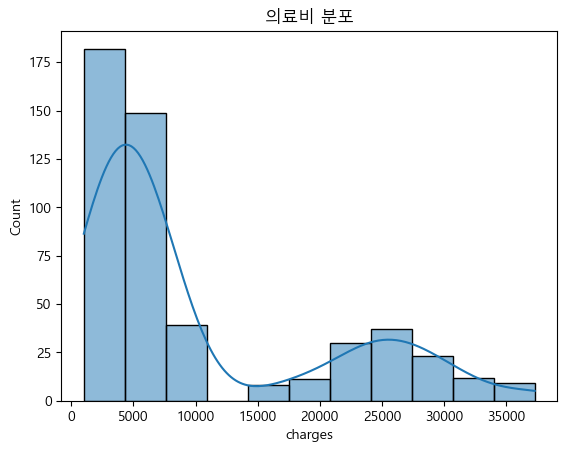

In [82]:
sns.histplot(df['charges'], kde=True)
plt.title('의료비 분포')

Text(0.5, 1.0, '지역별 고객 수')

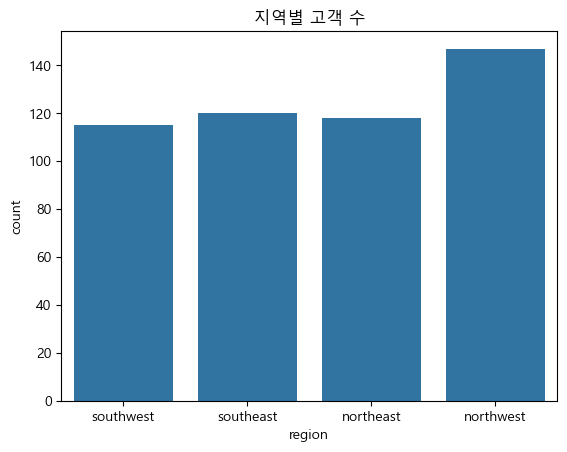

In [83]:
sns.countplot(data=df,x='region')
plt.title('지역별 고객 수')

#### 왜도 .skew()
- 데이터 분포가 좌우 대칭에서 얼마나, 어느 방향으로 치우쳐 있는지를 나타내는 지표
- 왜도가 0이면 좌우 대칭(정규분포처럼)
- 왜도가 0보다 크면 양의 왜도, 오른쪽으로 긴 꼬리 (대부분의 값은 작은 쪽에 몰려있다. 소수의 큰 값이 꼬리를 늘린다.)
- 왜도가 0보다 작으면 음의 왜도, 왼쪽으로 긴 꼬리 (대부분의 값은 큰 쪽에 몰려있다. 소수의 작은 값이 꼬리를 늘린다.)

In [84]:
# 의료비의 왜도
df['charges'].skew().round(3)

np.float64(1.204)

### 상관관계 분석

In [85]:
corr = df[['age','bmi','children','charges']].corr(numeric_only=True)
corr

,age,bmi,children,charges
age,1.000000,-0.011847,0.056462,0.048457
bmi,-0.011847,1.000000,-0.039397,0.054533
children,0.056462,-0.039397,1.000000,0.040232
charges,0.048457,0.054533,0.040232,1.000000


Text(0.5, 1.0, '수치형 변수 상관관계')

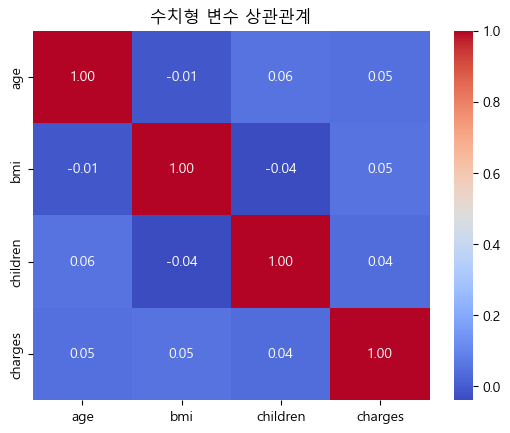

In [86]:
# 히트맵 그래프
sns.heatmap(data=corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('수치형 변수 상관관계')

In [87]:
np.ones(corr.shape) # 모두 1로 채운다.

array([[1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.]])

In [88]:
np.triu(np.ones(corr.shape), k=1)

array([[0., 1., 1., 1.],
       [0., 0., 1., 1.],
       [0., 0., 0., 1.],
       [0., 0., 0., 0.]])

In [89]:
np.triu(np.ones(corr.shape), k=1).astype(bool)

array([[False,  True,  True,  True],
       [False, False,  True,  True],
       [False, False, False,  True],
       [False, False, False, False]])

In [90]:
corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

,age,bmi,children,charges
age,NaN,-0.011847,0.056462,0.048457
bmi,NaN,NaN,-0.039397,0.054533
children,NaN,NaN,NaN,0.040232
charges,NaN,NaN,NaN,NaN


In [91]:
corr_pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()

In [92]:
# abs() : 절대값
top_pair = corr_pairs.abs().sort_values(ascending=False).index[0]

In [93]:
top_pair

('age', 'children')

Text(0.5, 1.0, 'age vs children')

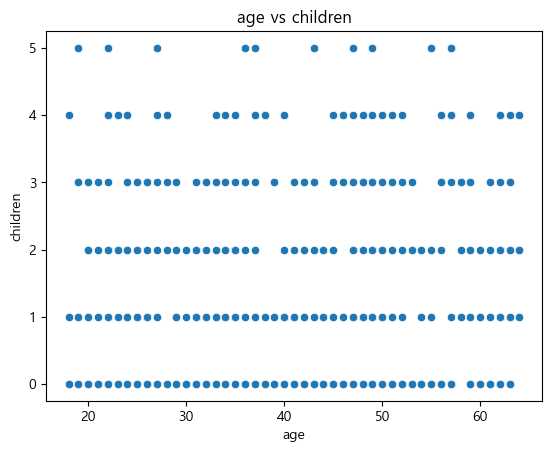

In [94]:
# 산포 그래프 - scatterplot()

sns.scatterplot(data=df, x=top_pair[0], y=top_pair[1])
plt.title(f'{top_pair[0]} vs {top_pair[1]}')

Text(0.5, 1.0, '흡연 여부별 의료비 분포')

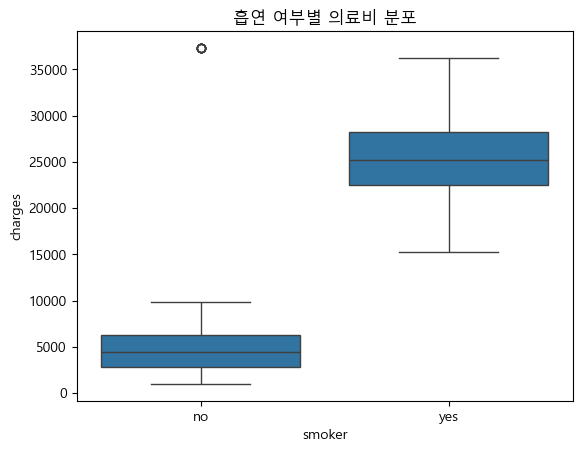

In [95]:
# 흡연 여부별 의료비 분포
sns.boxplot(data=df, x='smoker', y='charges')
plt.title('흡연 여부별 의료비 분포')

### 그룹별 비교 및 인사이트

In [96]:
# 흡연 유무 따른 의료비 평균
g1 = df.groupby('smoker')['charges'].mean()
g1

smoker
no      5230.566984
yes    25078.640492
Name: charges, dtype: float64

In [97]:
# 지역별 의료비 평균
g2 = df.groupby('region')['charges'].mean()
g2

region
northeast    11527.492595
northwest    10071.728350
southeast     9082.355240
southwest     9618.066413
Name: charges, dtype: float64

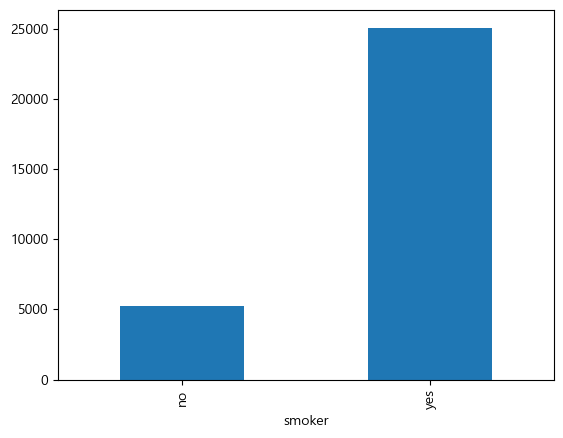

In [98]:
g1.plot(kind='bar')
plt.show()

In [99]:
#  encoding
df['sex'] = df['sex'].map({'male':1, 'female':0})

df['smoker_encoding'] = df['smoker'].map({'yes':1, 'no':0})

# 원핫 인코딩
df = pd.get_dummies(data=df, columns=['region'])

In [100]:
df

,age,sex,bmi,children,smoker,charges,smoker_encoding,region_northeast,region_northwest,region_southeast,region_southwest
0,56.0,0,22.7,4.0,no,3230.92,0,False,False,False,True
1,22.0,0,28.2,0.0,no,1601.92,0,False,False,True,False
2,26.0,1,30.2,3.0,no,4764.30,0,False,False,True,False
3,29.0,0,29.1,0.0,yes,26255.60,1,True,False,False,False
4,26.0,1,35.0,0.0,no,3914.46,0,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
495,49.0,1,27.1,0.0,no,7802.82,0,False,False,False,True
496,63.0,1,26.2,1.0,no,3967.26,0,True,False,False,False
497,34.0,0,34.6,2.0,no,3195.25,0,False,False,False,True
498,54.0,0,36.3,0.0,no,5341.74,0,True,False,False,False


### 파생 변수 생성 및 스케일링

In [101]:
# bmi 비율
df['bmi_age_ratio'] = df['bmi'] / df['age']

df.head()

,age,sex,bmi,children,smoker,charges,smoker_encoding,region_northeast,region_northwest,region_southeast,region_southwest,bmi_age_ratio
0,56.0,0,22.7,4.0,no,3230.92,0,False,False,False,True,0.405357
1,22.0,0,28.2,0.0,no,1601.92,0,False,False,True,False,1.281818
2,26.0,1,30.2,3.0,no,4764.30,0,False,False,True,False,1.161538
3,29.0,0,29.1,0.0,yes,26255.60,1,True,False,False,False,1.003448
4,26.0,1,35.0,0.0,no,3914.46,0,True,False,False,False,1.346154


In [102]:
scale_cols = ['age','bmi','charges','bmi_age_ratio']
df[scale_cols]

,age,bmi,charges,bmi_age_ratio
0,56.0,22.7,3230.92,0.405357
1,22.0,28.2,1601.92,1.281818
2,26.0,30.2,4764.30,1.161538
3,29.0,29.1,26255.60,1.003448
4,26.0,35.0,3914.46,1.346154
...,...,...,...,...
495,49.0,27.1,7802.82,0.553061
496,63.0,26.2,3967.26,0.415873
497,34.0,34.6,3195.25,1.017647
498,54.0,36.3,5341.74,0.672222


In [103]:
df[scale_cols].describe().loc[['mean','std']] # 스케일링 전 -평균, 표준편차

,age,bmi,charges,bmi_age_ratio
mean,40.782000,30.196000,10073.496920,0.840124
std,13.322517,5.719427,9885.701215,0.366819


In [104]:
scaler = StandardScaler() # 표준화 스케일링
df[scale_cols] = scaler.fit_transform(df[scale_cols]) # 학습 및 변환

df[scale_cols].describe().loc[['mean','std']] # 스케일링 전 -평균, 표준편차

,age,bmi,charges,bmi_age_ratio
mean,2.309264e-16,-2.771117e-16,-1.456613e-16,2.486900e-16
std,1.001002e+00,1.001002e+00,1.001002e+00,1.001002e+00


### 최종 전처리 작업한 파일을 csv 파일로 내보내기

In [105]:
df.to_csv('insurance_final.csv', index=False)

In [106]:
pd.read_csv('insurance_final.csv')

,age,sex,bmi,children,smoker,charges,smoker_encoding,region_northeast,region_northwest,region_southeast,region_southwest,bmi_age_ratio
0,1.143421,0,-1.311933,4.0,no,-0.692862,0,False,False,False,True,-1.186424
1,-1.411206,0,-0.349336,0.0,no,-0.857811,0,False,False,True,False,1.205328
2,-1.110661,1,0.000700,3.0,no,-0.537596,0,False,False,True,False,0.877100
3,-0.885253,0,-0.191819,0.0,yes,1.638559,1,True,False,False,False,0.445691
4,-1.110661,1,0.840785,0.0,no,-0.623649,0,True,False,False,False,1.380892
...,...,...,...,...,...,...,...,...,...,...,...,...
495,0.617468,1,-0.541855,0.0,no,-0.229923,0,False,False,False,True,-0.783358
496,1.669373,1,-0.699371,1.0,no,-0.618302,0,True,False,False,False,-1.157727
497,-0.509573,0,0.770778,2.0,no,-0.696474,0,False,False,False,True,0.484438
498,0.993149,0,1.068309,0.0,no,-0.479126,0,True,False,False,False,-0.458183
